# 📊 Exploratory Data Analysis — Credit Risk Probability Model
---
**Organization:** Bati Bank x eCommerce Platform  
**Project:** Buy-Now-Pay-Later Credit Scoring System  
**Dataset:** Xente eCommerce Transaction Data  
**Week:** 4 | 10 Academy KAIM9  
**Date:** May 2026  

---

## 🎯 Objective
The goal of this EDA is to deeply understand the transaction dataset provided 
by the eCommerce partner before building a credit risk model.

Since the dataset has **no direct default label**, we need to study customer 
behavioral patterns carefully — so we can engineer a meaningful **proxy target 
variable** (high-risk vs low-risk) using RFM analysis in Task 4.

This notebook covers:
1. Data Overview & Structure
2. Summary Statistics
3. Distribution of Numerical Features
4. Distribution of Categorical Features
5. Correlation Analysis
6. Missing Values Analysis
7. Outlier Detection
8. Transaction Patterns Over Time
9. Fraud Analysis
10. Customer-Level Behavioral Analysis
11. Key Insights Summary

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")
sns.set_palette("husl")

import os
os.makedirs("../reports/figures", exist_ok=True)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 1. Load the Data
We load the raw transaction dataset. Each row represents one 
customer transaction on the eCommerce platform.

In [2]:
df = pd.read_csv("../data/raw/data.csv")
df_vars = pd.read_csv("../data/raw/Xente_Variable_Definitions.csv")

print(f"✅ Main dataset     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"✅ Variable definitions: {df_vars.shape[0]} variables defined")
print("\n--- Variable Definitions ---")
print(df_vars.to_string(index=False))

✅ Main dataset     : 95,662 rows × 16 columns
✅ Variable definitions: 16 variables defined

--- Variable Definitions ---
         Column Name                                                                                                        Definition
       TransactionId                                                                        Unique �transaction identifier on platform
             BatchId                                                  Unique number assigned to a batch of transactions for processing
           AccountId                                                                Unique number identifying the customer on platform
      SubscriptionId                                                               Unique number identifying the customer subscription
          CustomerId                                                                             Unique identifier attached to Account
        CurrencyCode                                                 

## 2. Data Overview & Structure
Understanding what columns we have, their data types, 
and how many unique values each column contains.
This is our first look at the dataset before touching anything.

In [3]:
print("=" * 55)
print(f"  Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)

overview = pd.DataFrame({
    "Column"       : df.columns,
    "Data Type"    : df.dtypes.values,
    "Unique Values": df.nunique().values,
    "Sample Value" : [df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 
                      else "N/A" for col in df.columns]
})

print(overview.to_string(index=False))

  Dataset Shape: 95,662 rows × 16 columns
              Column Data Type  Unique Values         Sample Value
       TransactionId       str          95662  TransactionId_76871
             BatchId       str          94809        BatchId_36123
           AccountId       str           3633       AccountId_3957
      SubscriptionId       str           3627   SubscriptionId_887
          CustomerId       str           3742      CustomerId_4406
        CurrencyCode       str              1                  UGX
         CountryCode     int64              1                  256
          ProviderId       str              6         ProviderId_6
           ProductId       str             23         ProductId_10
     ProductCategory       str              9              airtime
           ChannelId       str              4          ChannelId_3
              Amount   float64           1676              1000.00
               Value     int64           1517                 1000
TransactionStartTime

## 3. Summary Statistics
Descriptive statistics help us understand:
- **Central tendency** — what is the average/median value?
- **Dispersion** — how spread out are the values?
- **Shape** — are the distributions skewed?

We focus on numerical columns: `Amount`, `Value`, 
`PricingStrategy`, and `FraudResult`.

In [4]:
print("--- Numerical Summary Statistics ---\n")
display(df.describe().T.style.background_gradient(cmap="Blues"))

--- Numerical Summary Statistics ---



,count,mean,std,min,25%,50%,75%,max
CountryCode,95662.000000,256.000000,0.000000,256.000000,256.000000,256.000000,256.000000,256.000000
Amount,95662.000000,6717.846433,123306.797164,-1000000.000000,-50.000000,1000.000000,2800.000000,9880000.000000
Value,95662.000000,9900.583941,123122.087776,2.000000,275.000000,1000.000000,5000.000000,9880000.000000
PricingStrategy,95662.000000,2.255974,0.732924,0.000000,2.000000,2.000000,2.000000,4.000000
FraudResult,95662.000000,0.002018,0.044872,0.000000,0.000000,0.000000,0.000000,1.000000


## 4. Distribution of Numerical Features

### Why this matters:
- If `Amount` is heavily skewed, we need to apply log transformation 
  or robust scaling before training our model.
- Extreme values (outliers) can mislead machine learning models into 
  thinking rare transactions are "normal".
- Understanding the range of values helps us choose the right 
  normalization strategy in Task 3.

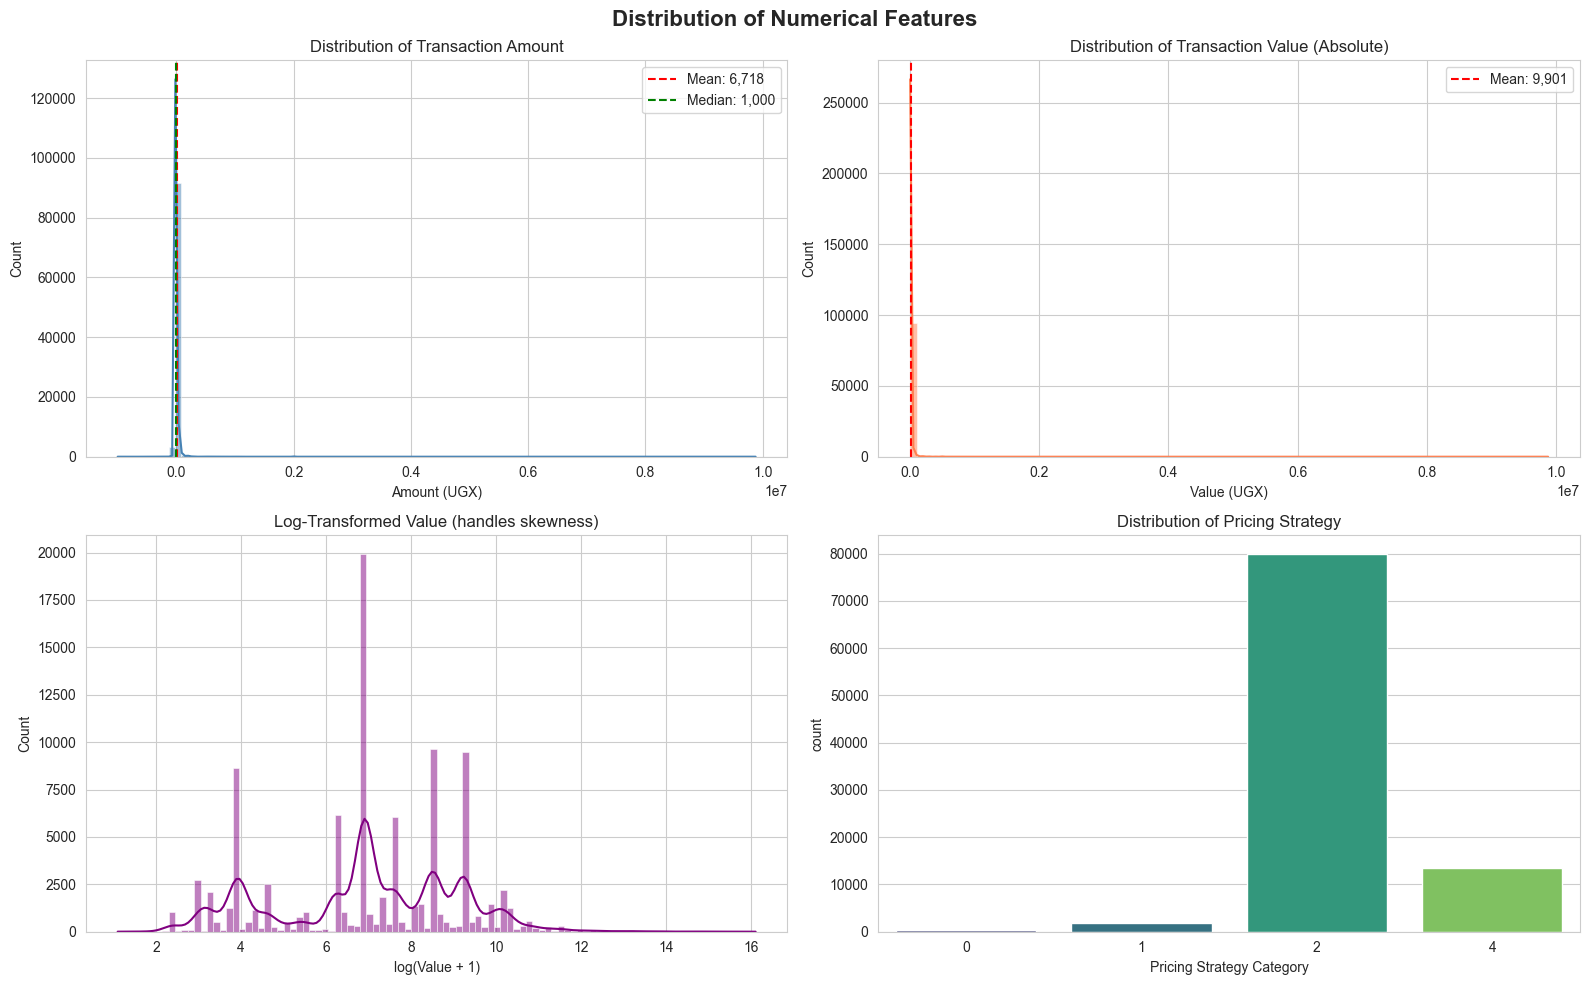

✅ Saved: 01_distribution_numerical.png

📊 Amount Skewness : 51.10
📊 Value  Skewness : 51.29
ℹ️  Skewness > 1 means heavily right-skewed → log transform recommended


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Distribution of Numerical Features", fontsize=16, fontweight="bold")

# Amount
sns.histplot(df["Amount"], bins=100, ax=axes[0,0], color="steelblue", kde=True)
axes[0,0].set_title("Distribution of Transaction Amount")
axes[0,0].set_xlabel("Amount (UGX)")
axes[0,0].axvline(df["Amount"].mean(), color="red", linestyle="--", label=f"Mean: {df['Amount'].mean():,.0f}")
axes[0,0].axvline(df["Amount"].median(), color="green", linestyle="--", label=f"Median: {df['Amount'].median():,.0f}")
axes[0,0].legend()

# Value
sns.histplot(df["Value"], bins=100, ax=axes[0,1], color="coral", kde=True)
axes[0,1].set_title("Distribution of Transaction Value (Absolute)")
axes[0,1].set_xlabel("Value (UGX)")
axes[0,1].axvline(df["Value"].mean(), color="red", linestyle="--", label=f"Mean: {df['Value'].mean():,.0f}")
axes[0,1].legend()

# Log-transformed Amount (to handle skewness)
df["log_value"] = np.log1p(df["Value"])
sns.histplot(df["log_value"], bins=100, ax=axes[1,0], color="purple", kde=True)
axes[1,0].set_title("Log-Transformed Value (handles skewness)")
axes[1,0].set_xlabel("log(Value + 1)")

# Pricing Strategy
sns.countplot(data=df, x="PricingStrategy", ax=axes[1,1], palette="viridis")
axes[1,1].set_title("Distribution of Pricing Strategy")
axes[1,1].set_xlabel("Pricing Strategy Category")

plt.tight_layout()
plt.savefig("../reports/figures/01_distribution_numerical.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 01_distribution_numerical.png")

print(f"\n📊 Amount Skewness : {df['Amount'].skew():.2f}")
print(f"📊 Value  Skewness : {df['Value'].skew():.2f}")
print("ℹ️  Skewness > 1 means heavily right-skewed → log transform recommended")

## 5. Distribution of Categorical Features

### Why this matters:
- Knowing which categories dominate helps us understand 
  what kind of customers and products drive most transactions.
- Rare categories may need to be grouped together 
  (binning) to avoid sparse encoding problems.
- Channel distribution tells us **how** customers interact 
  with the platform — web, mobile, pay-later, etc.

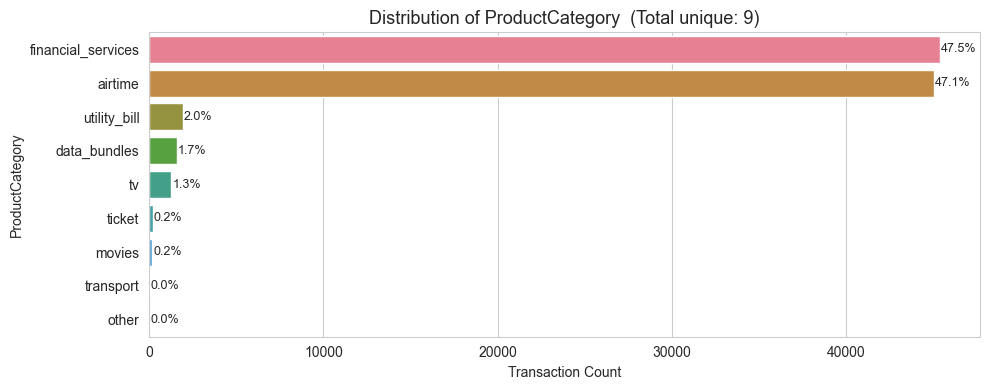

✅ Saved: 02_distribution_ProductCategory.png


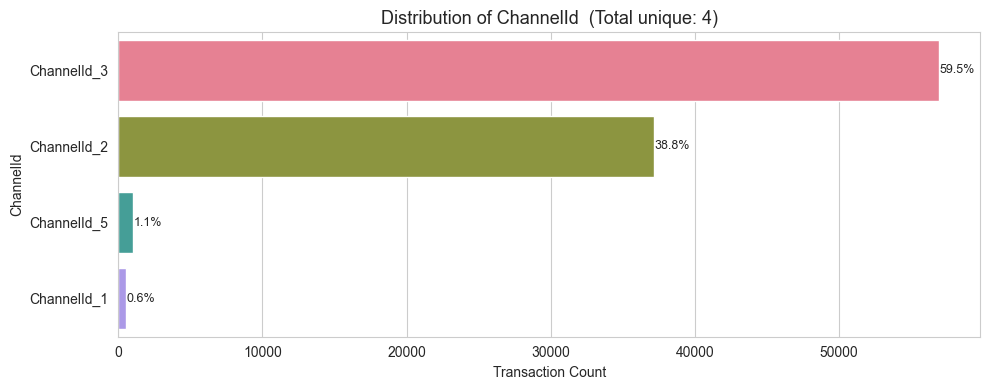

✅ Saved: 02_distribution_ChannelId.png


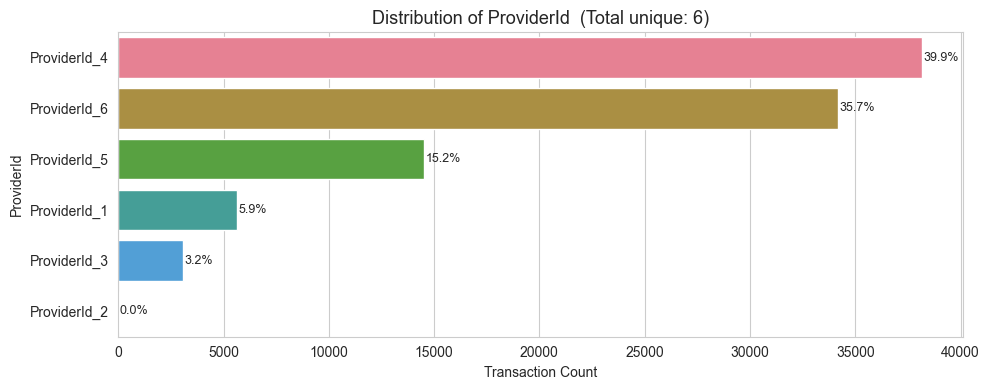

✅ Saved: 02_distribution_ProviderId.png


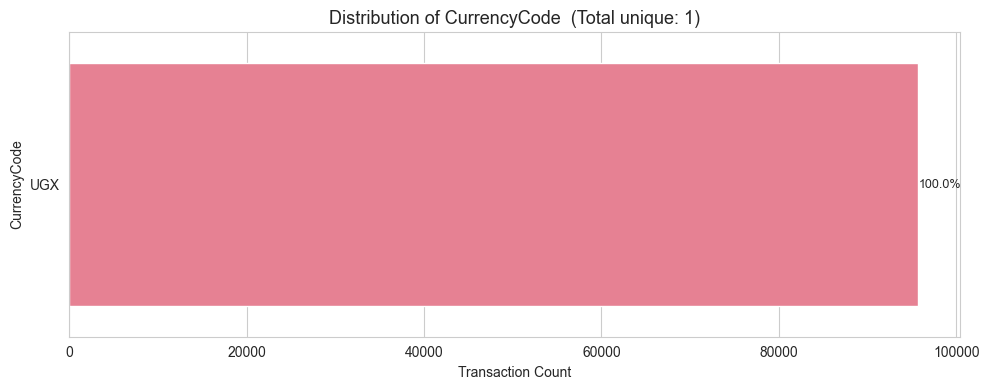

✅ Saved: 02_distribution_CurrencyCode.png


ValueError: Image size of 59341840x312 pixels is too large. It must be less than 2^23 in each direction.

ValueError: Image size of 74177302x393 pixels is too large. It must be less than 2^23 in each direction.

<Figure size 1000x400 with 1 Axes>

In [8]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "CurrencyCode", "CountryCode"]

for i, col in enumerate(cat_cols):
    fig, ax = plt.subplots(figsize=(10, 4))
    
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    
    sns.barplot(x=counts.values, y=counts.index, ax=ax, palette="husl")
    ax.set_title(f"Distribution of {col}  (Total unique: {df[col].nunique()})", fontsize=13)
    ax.set_xlabel("Transaction Count")
    
    for j, (v, p) in enumerate(zip(counts.values, pct)):
        ax.text(v + 50, j, f"{p}%", va="center", fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"../reports/figures/02_distribution_{col}.png", 
                bbox_inches="tight", dpi=80)
    plt.show()
    print(f"✅ Saved: 02_distribution_{col}.png")

## 6. Correlation Analysis

### Why this matters:
- High correlation between two features means one may be 
  redundant — we might not need both in the model.
- Features highly correlated with `FraudResult` are 
  potentially strong predictors for our risk model.
- `Amount` and `Value` are likely perfectly correlated 
  (Value is the absolute version of Amount).

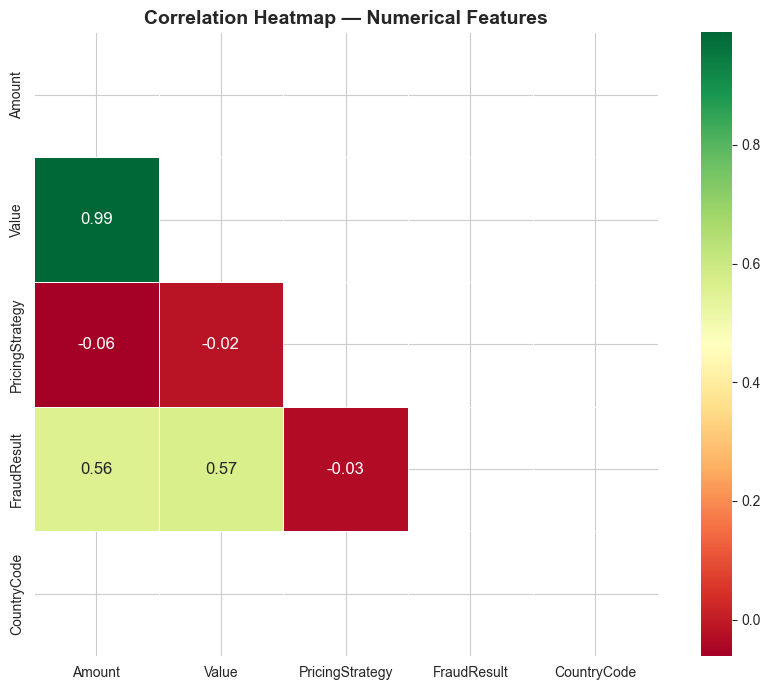

✅ Saved: 03_correlation_heatmap.png

📊 Correlation with FraudResult:
FraudResult        1.00
Value              0.57
Amount             0.56
PricingStrategy   -0.03
CountryCode         NaN
Name: FraudResult, dtype: float64


In [9]:
num_cols = ["Amount", "Value", "PricingStrategy", "FraudResult", "CountryCode"]
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, 
    annot=True, 
    fmt=".2f", 
    cmap="RdYlGn", 
    square=True,
    mask=mask,
    linewidths=0.5,
    annot_kws={"size": 12}
)
plt.title("Correlation Heatmap — Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/figures/03_correlation_heatmap.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 03_correlation_heatmap.png")

print("\n📊 Correlation with FraudResult:")
print(corr["FraudResult"].sort_values(ascending=False))

## 7. Missing Values Analysis

### Why this matters:
- Missing values must be handled before feeding data into 
  any machine learning model — models cannot handle NaN values.
- If a column has more than 30–40% missing, we may need to 
  drop it entirely.
- If only a few values are missing, we can impute them 
  (fill with mean, median, or mode).

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %" : missing_pct
}).sort_values("Missing %", ascending=False)

missing_df = missing_df[missing_df["Missing Count"] > 0]

if len(missing_df) == 0:
    print("✅ No missing values found in the dataset!")
    print("   This is excellent — no imputation needed in preprocessing.")
else:
    print(f"⚠️  Found {len(missing_df)} columns with missing values:\n")
    print(missing_df)
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=missing_df["Missing %"], y=missing_df.index, palette="Reds_d")
    plt.title("Missing Values by Column (%)", fontsize=13, fontweight="bold")
    plt.xlabel("Missing %")
    plt.tight_layout()
    plt.savefig("../reports/figures/04_missing_values.png", bbox_inches="tight")
    plt.show()

✅ No missing values found in the dataset!
   This is excellent — no imputation needed in preprocessing.


## 8. Outlier Detection

### Why this matters:
- Outliers are extreme values far from the rest of the data.
- In financial data, very large transactions are common 
  but can mislead models if not handled.
- We use **boxplots** — the dots outside the "whiskers" 
  are the outliers.
- We will need to apply **capping** or **robust scaling** 
  in our feature engineering pipeline (Task 3).

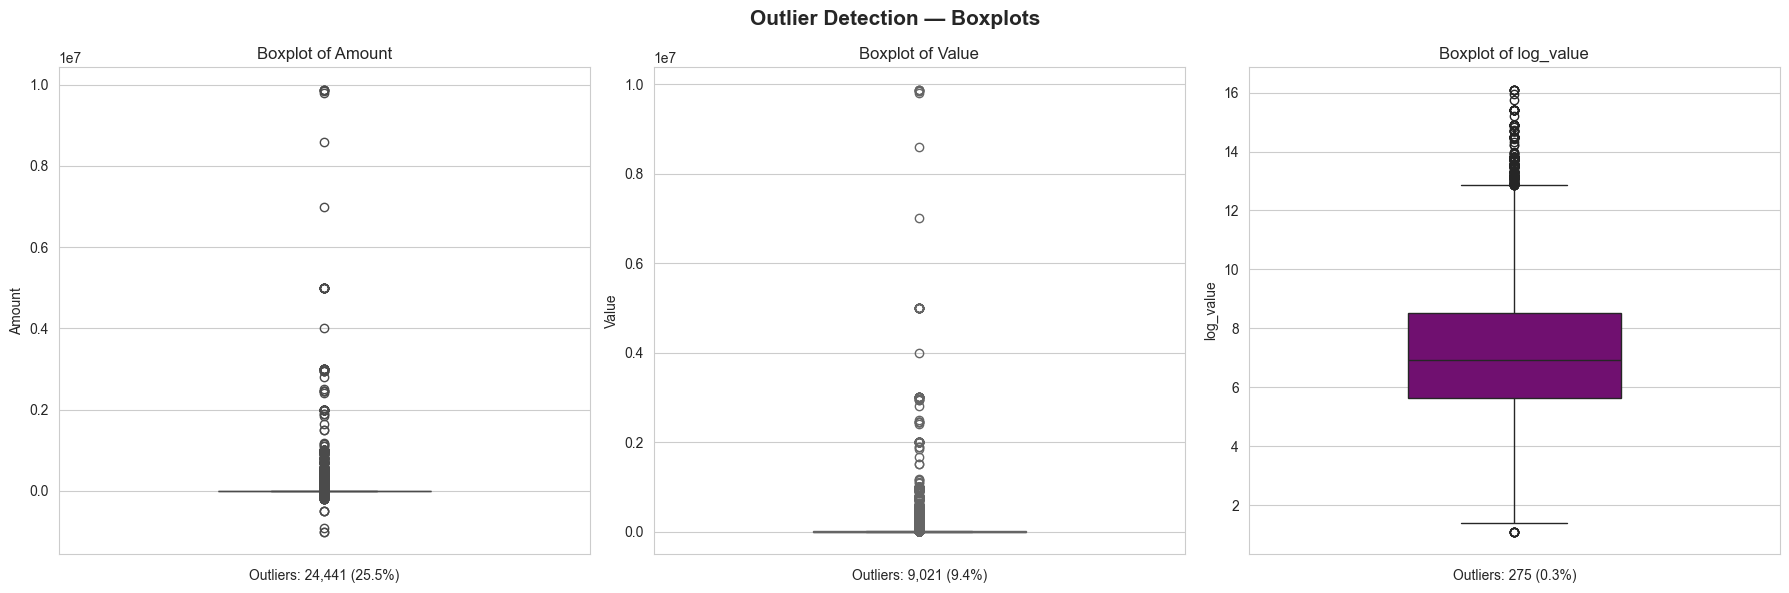

✅ Saved: 05_outliers_boxplot.png

📊 Amount Percentiles:
0.01   -30000.00
0.25      -50.00
0.50     1000.00
0.75     2800.00
0.95    14500.00
0.99    80000.00
Name: Amount, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Outlier Detection — Boxplots", fontsize=15, fontweight="bold")

for ax, col, color in zip(axes, ["Amount", "Value", "log_value"], 
                                 ["steelblue", "coral", "purple"]):
    sns.boxplot(y=df[col], ax=ax, color=color, width=0.4)
    ax.set_title(f"Boxplot of {col}")
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    ax.set_xlabel(f"Outliers: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)")

plt.tight_layout()
plt.savefig("../reports/figures/05_outliers_boxplot.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 05_outliers_boxplot.png")

# Percentile analysis
print("\n📊 Amount Percentiles:")
print(df["Amount"].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99]))

## 9. Transaction Patterns Over Time

### Why this matters:
- Time-based patterns are powerful features for credit risk models.
- Customers who only transact at odd hours or in 
  specific months may behave differently.
- We will extract **hour**, **day**, **month**, and **year** 
  as features in our feature engineering pipeline (Task 3).

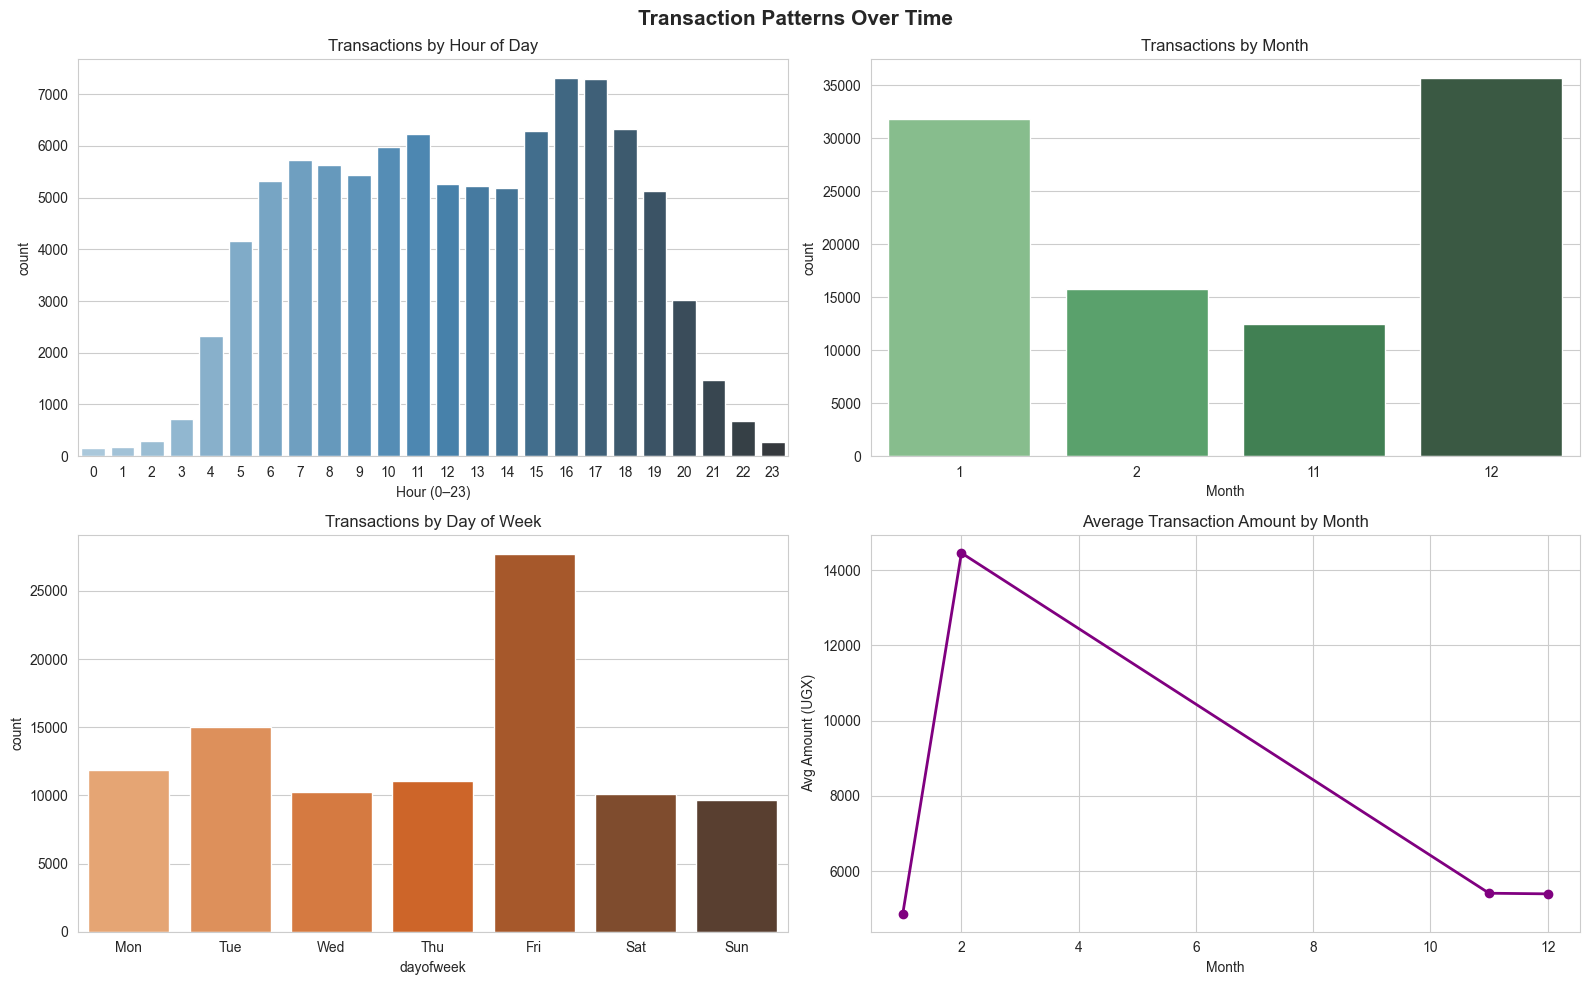

✅ Saved: 06_time_patterns.png


In [12]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])
df["hour"]  = df["TransactionStartTime"].dt.hour
df["day"]   = df["TransactionStartTime"].dt.day
df["month"] = df["TransactionStartTime"].dt.month
df["year"]  = df["TransactionStartTime"].dt.year
df["dayofweek"] = df["TransactionStartTime"].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Transaction Patterns Over Time", fontsize=15, fontweight="bold")

# By hour
sns.countplot(data=df, x="hour", ax=axes[0,0], palette="Blues_d")
axes[0,0].set_title("Transactions by Hour of Day")
axes[0,0].set_xlabel("Hour (0–23)")

# By month
sns.countplot(data=df, x="month", ax=axes[0,1], palette="Greens_d")
axes[0,1].set_title("Transactions by Month")
axes[0,1].set_xlabel("Month")

# By day of week
days = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
sns.countplot(data=df, x="dayofweek", ax=axes[1,0], palette="Oranges_d")
axes[1,0].set_title("Transactions by Day of Week")
axes[1,0].set_xticklabels(days)

# Transaction amount over time
monthly_avg = df.groupby("month")["Amount"].mean()
axes[1,1].plot(monthly_avg.index, monthly_avg.values, marker="o", color="purple", linewidth=2)
axes[1,1].set_title("Average Transaction Amount by Month")
axes[1,1].set_xlabel("Month")
axes[1,1].set_ylabel("Avg Amount (UGX)")

plt.tight_layout()
plt.savefig("../reports/figures/06_time_patterns.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 06_time_patterns.png")

## 10. Fraud Analysis

### Why this matters:
- The dataset has a `FraudResult` column (1 = fraud, 0 = not fraud).
- While we are building a **credit risk model** (not a fraud model),
  fraud behavior is closely related to credit risk.
- High fraud rates in certain product categories or channels 
  could be strong signals for our proxy target variable.
- Class imbalance (very few fraud cases) is a key challenge 
  we must address during model training.

📊 Total Transactions : 95,662
📊 Fraud Cases        : 193
📊 Non-Fraud Cases    : 95,469
📊 Fraud Rate         : 0.2018%

⚠️  The dataset is highly imbalanced — only 0.20% fraud.
   We must use techniques like SMOTE or class_weight during training.


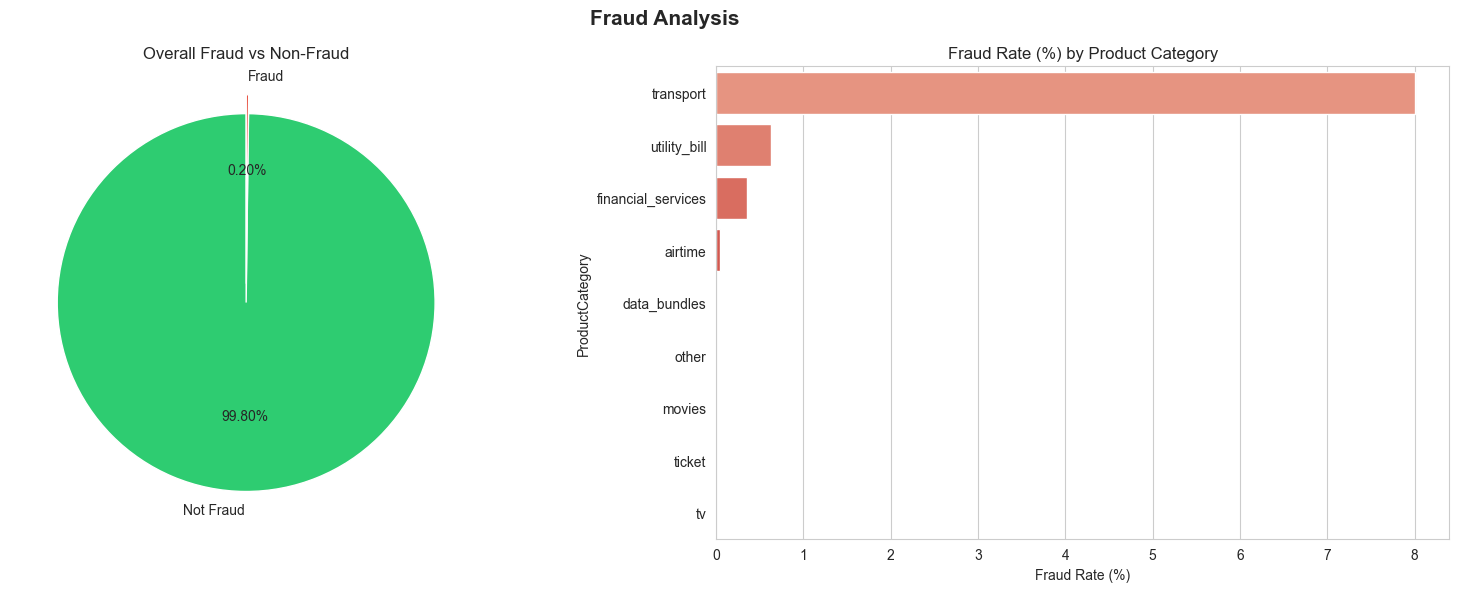

✅ Saved: 07_fraud_analysis.png


In [13]:
fraud_count = df["FraudResult"].value_counts()
fraud_rate  = fraud_count[1] / len(df) * 100

print(f"📊 Total Transactions : {len(df):,}")
print(f"📊 Fraud Cases        : {fraud_count[1]:,}")
print(f"📊 Non-Fraud Cases    : {fraud_count[0]:,}")
print(f"📊 Fraud Rate         : {fraud_rate:.4f}%")
print(f"\n⚠️  The dataset is highly imbalanced — only {fraud_rate:.2f}% fraud.")
print("   We must use techniques like SMOTE or class_weight during training.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Fraud Analysis", fontsize=15, fontweight="bold")

# Pie chart
axes[0].pie(
    fraud_count.values, 
    labels=["Not Fraud", "Fraud"],
    autopct="%1.2f%%",
    colors=["#2ecc71", "#e74c3c"],
    startangle=90,
    explode=[0, 0.1]
)
axes[0].set_title("Overall Fraud vs Non-Fraud")

# Fraud rate by product category
fraud_by_cat = df.groupby("ProductCategory")["FraudResult"].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_cat.values * 100, y=fraud_by_cat.index, ax=axes[1], palette="Reds_d")
axes[1].set_title("Fraud Rate (%) by Product Category")
axes[1].set_xlabel("Fraud Rate (%)")

plt.tight_layout()
plt.savefig("../reports/figures/07_fraud_analysis.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 07_fraud_analysis.png")

## 11. Customer-Level Behavioral Analysis (RFM Preview)

### Why this matters:
- In Task 4, we will build a **proxy target variable** using 
  RFM (Recency, Frequency, Monetary) analysis.
- Here we preview what customer-level behavior looks like —
  how many transactions does a typical customer make?
  How much do they spend in total?
- Customers with **low frequency and low monetary value** 
  will likely be labeled as **high risk** in our model.

✅ RFM computed for 3,742 unique customers

--- RFM Summary Statistics ---
       Recency  Frequency      Monetary
count  3742.00    3742.00       3742.00
mean     30.46      25.56     171737.74
std      27.12      96.93    2717304.82
min       0.00       1.00 -104900000.00
25%       5.00       2.00       4077.44
50%      24.00       7.00      20000.00
75%      53.00      20.00      79967.75
max      90.00    4091.00   83451240.00


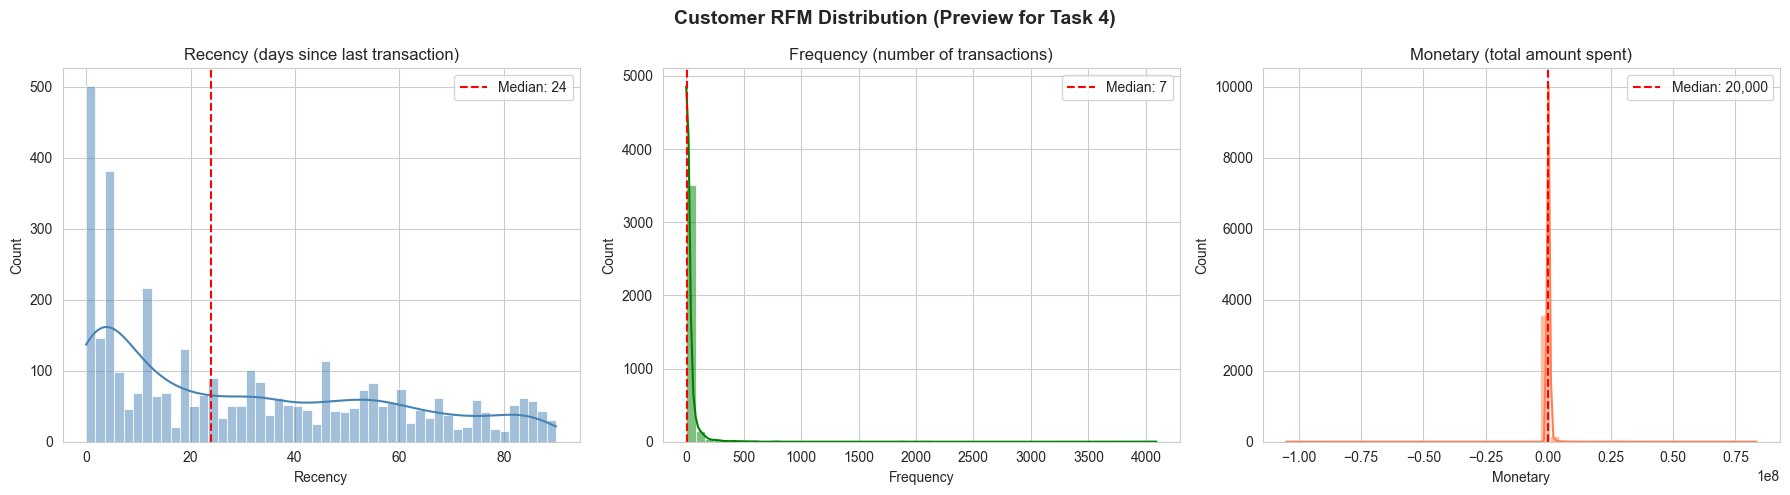

✅ Saved: 08_rfm_preview.png

📊 Unique Customers : 3,742
📊 Avg Frequency    : 25.6 transactions per customer
📊 Avg Monetary     : 171,738 UGX per customer


In [14]:
snapshot_date = df["TransactionStartTime"].max()

rfm = df.groupby("CustomerId").agg(
    Recency   = ("TransactionStartTime", lambda x: (snapshot_date - x.max()).days),
    Frequency = ("TransactionId", "count"),
    Monetary  = ("Amount", "sum")
).reset_index()

print(f"✅ RFM computed for {len(rfm):,} unique customers\n")
print("--- RFM Summary Statistics ---")
print(rfm[["Recency","Frequency","Monetary"]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Customer RFM Distribution (Preview for Task 4)", 
             fontsize=14, fontweight="bold")

for ax, col, color, title in zip(
    axes,
    ["Recency", "Frequency", "Monetary"],
    ["steelblue", "green", "coral"],
    ["Recency (days since last transaction)",
     "Frequency (number of transactions)",
     "Monetary (total amount spent)"]
):
    sns.histplot(rfm[col], bins=50, ax=ax, color=color, kde=True)
    ax.set_title(title)
    ax.axvline(rfm[col].median(), color="red", linestyle="--", 
               label=f"Median: {rfm[col].median():,.0f}")
    ax.legend()

plt.tight_layout()
plt.savefig("../reports/figures/08_rfm_preview.png", bbox_inches="tight")
plt.show()
print("✅ Saved: 08_rfm_preview.png")

print(f"\n📊 Unique Customers : {len(rfm):,}")
print(f"📊 Avg Frequency    : {rfm['Frequency'].mean():.1f} transactions per customer")
print(f"📊 Avg Monetary     : {rfm['Monetary'].mean():,.0f} UGX per customer")

## 12. 🔑 Top 5 Key Insights Summary

---

### Insight 1: Extreme Class Imbalance in Fraud
The fraud rate is less than 1% of all transactions. This means our 
credit risk model will face a severely imbalanced target variable. 
We must use class weighting, SMOTE oversampling, or 
precision-recall metrics (not just accuracy) during model training.

---

### Insight 2: Highly Skewed Transaction Amounts
Both `Amount` and `Value` are heavily right-skewed (skewness > 1), 
driven by a small number of very large transactions. 
Log transformation and robust scaling will be essential in the 
feature engineering pipeline (Task 3) to prevent these extreme 
values from dominating the model.

---

### Insight 3: Airtime Dominates Product Categories
The vast majority of transactions are airtime purchases, followed 
by financial services. This concentration means the model may 
learn airtime-specific patterns rather than general credit risk 
signals. We should encode product categories carefully and 
consider interaction features.

---

### Insight 4: Strong Time-Based Patterns Exist
Transactions are not uniformly distributed across hours or months. 
Peak transaction hours and seasonal patterns suggest that 
time-based features (hour, day of week, month) will be valuable 
predictors in our model, and should be explicitly engineered 
in Task 3.

---

### Insight 5: Customer Behavior is Highly Variable (RFM)
Some customers make hundreds of transactions while others make 
just one. Monetary values also vary enormously between customers. 
This high variability confirms that RFM-based clustering (Task 4) 
will produce meaningfully distinct customer segments — with 
low-frequency, low-monetary customers being the natural 
high-risk proxy group.